
# Flare times on a GOES XRS plot

How to plot flare times as provided by the HEK on a GOES XRS plot.


In [1]:
import matplotlib.pyplot as plt

from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.time import parse_time
from sunpy.timeseries import TimeSeries

Let's grab GOES XRS data for a particular time of interest and the HEK flare
data for this time from the NOAA Space Weather Prediction Center (SWPC).
Here we are searching for data from the GOES-15 satellite and for the 1-min average time-sampled data.



In [10]:
tr = a.Time('2025-10-06 08:00', '2025-10-06 10:00')
results = Fido.search(tr, a.Instrument.xrs & a.goes.SatelliteNumber(18) & a.Resolution("avg1m") | a.hek.FL & (a.hek.FRM.Name == 'SWPC'))

Then download the XRS data and load it into a TimeSeries.



In [11]:
files = Fido.fetch(results)
goes = TimeSeries(files)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Next let's retrieve `~sunpy.net.hek.HEKTable` from the Fido result
and then load the first row from HEK results into ``flares_hek``.



In [12]:
hek_results = results['hek']
flares_hek = hek_results[0]

Lets plot everything together.



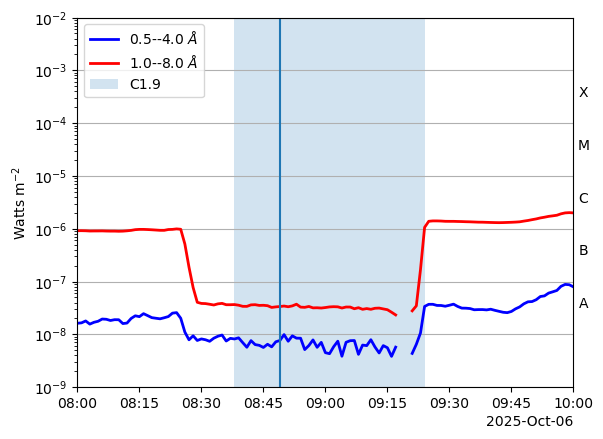

In [13]:
fig, ax = plt.subplots()
goes.plot(axes=ax)
ax.axvline(parse_time(flares_hek['event_peaktime']).datetime)
ax.axvspan(
    parse_time(flares_hek['event_starttime']).datetime,
    parse_time(flares_hek['event_endtime']).datetime,
    alpha=0.2, label=flares_hek['fl_goescls']
)
ax.legend(loc=2)
ax.set_yscale('log')
ax.set_xlim(tr.start.to_datetime(), tr.end.to_datetime())

plt.show()